# Isolation Forest Anomaly Detector — `transactions_raw.csv` (standalone)

Unsupervised anomaly detection on the raw transactions file **only**:
no fraud labels in training, no `customer_profiles` join.

**Pipeline:** Load & verify → logic-aware cleaning → feature engineering
(incl. within-file account context) → encoding → scale + IsolationForest →
score & inspect → save model/scaler/features to Drive.

Run cells top to bottom. Every stage prints a `[CHECKPOINT]` so you can audit it.


## Cell 0 — Setup: imports + environment-aware paths

Runs in **two environments** with no edits:
- **Colab** → mounts Drive, reads/writes the `MyDrive/datasets*` + `MyDrive/models` paths.
- **Local repo run** (Jupyter/VS Code from `backend/` or `backend/notebooks/`) →
  reads `backend/datasets/transactions_raw.csv`, saves to `backend/models/` and
  `backend/datasets_processed/`.


In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_PATH     = "/content/drive/MyDrive/datasets/transactions_raw.csv"
    LABELS_PATH   = "/content/drive/MyDrive/datasets/fraud_labels_train.csv"  # optional diagnostic only
    PROCESSED_DIR = "/content/drive/MyDrive/datasets_processed"
    MODEL_DIR     = "/content/drive/MyDrive/models"
else:
    # Local run: walk up from cwd until we find the backend dir (the one holding datasets/).
    base = Path.cwd()
    while not (base / "datasets" / "transactions_raw.csv").exists():
        if base.parent == base:
            raise FileNotFoundError(
                "Could not locate backend/datasets/transactions_raw.csv above "
                f"{Path.cwd()} — run this notebook from backend/ or backend/notebooks/."
            )
        base = base.parent
    DATA_PATH     = str(base / "datasets" / "transactions_raw.csv")
    LABELS_PATH   = str(base / "datasets" / "fraud_labels_train.csv")  # optional diagnostic only
    PROCESSED_DIR = str(base / "datasets_processed")
    MODEL_DIR     = str(base / "models")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE  = 42
EXPECTED_ROWS = 2_000_000

pd.set_option("display.width", 160)
print("[CHECKPOINT] Setup OK —", "Colab/Drive" if IN_COLAB else "local repo run")
print("  data   :", DATA_PATH)
print("  outputs:", PROCESSED_DIR, "|", MODEL_DIR)


[CHECKPOINT] Setup OK — local repo run
  data   : C:\Developer\Agentic-Fraud-Detection-System-\backend\datasets\transactions_raw.csv
  outputs: C:\Developer\Agentic-Fraud-Detection-System-\backend\datasets_processed | C:\Developer\Agentic-Fraud-Detection-System-\backend\models


## Step 1 — Load + verify

The file has truncated on Drive upload before, so we **hard-stop** if the row
count isn't exactly 2,000,000. Then dedupe on `txn_id` (1 known duplicate in source).


In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"], low_memory=False)

print("[CHECKPOINT] Loaded:", df.shape)

# Guard against a silently truncated Drive upload — stop here if short.
assert len(df) == EXPECTED_ROWS, (
    f"Row count {len(df):,} != {EXPECTED_ROWS:,} — the CSV is truncated/corrupted. "
    "Re-upload transactions_raw.csv before continuing."
)

n_before = len(df)
df = df.drop_duplicates(subset="txn_id", keep="first").reset_index(drop=True)
print(f"[CHECKPOINT] Dedupe on txn_id: removed {n_before - len(df)} duplicate(s) -> {len(df):,} rows")

assert df["timestamp"].isna().sum() == 0, "timestamp failed to parse on some rows"
print("[CHECKPOINT] timestamp parsed:", df['timestamp'].min(), "->", df['timestamp'].max())


[CHECKPOINT] Loaded: (2000000, 19)


[CHECKPOINT] Dedupe on txn_id: removed 2 duplicate(s) -> 1,999,998 rows
[CHECKPOINT] timestamp parsed: 2025-01-01 00:00:12.274000 -> 2026-05-31 23:59:58.484000


## Step 2 — Cleaning (logic-aware, not blanket imputation)

Nulls here are **business-logic absences**, not missing data:

| column | null rate | meaning of null | action |
|---|---|---|---|
| `fx_rate` | ~98.7% | domestic txn | **drop** — `is_international` already carries the cross-border signal |
| `terminal_id` | ~65% | non-POS/ATM channel | presence flag `has_terminal` |
| `session_id` | ~15% | no online session | presence flag `has_session` |
| `notes` | ~40% | no free text | flag `has_notes` (never feed raw text to IF) |
| `merchant_category_code` | ~4.2% | uncategorized | fill `"UNKNOWN"`, one-hot later |

`device_id` gets a `device_id_missing` flag for the same reason. No mode/median fills anywhere.


In [3]:
null_before = df.isna().mean().sort_values(ascending=False)
print("[CHECKPOINT] Null rates BEFORE cleaning (nonzero only):")
print((null_before[null_before > 0] * 100).round(2).astype(str) + " %")

# Presence flags for high-cardinality ID columns — we never impute or one-hot IDs.
df["has_terminal"]      = df["terminal_id"].notna()
df["has_session"]       = df["session_id"].notna()
df["device_id_missing"] = df["device_id"].isna()

# notes: sparse free text -> boolean only. Raw text never enters the feature matrix.
df["has_notes"] = df["notes"].notna()

# fx_rate: ~98.7% null and only set for international txns. is_international already
# captures the fraud-relevant cross-border signal, so the column adds nothing but noise.
# Dropping it entirely — median-filling a 98.7%-null column would fabricate data.
df = df.drop(columns=["fx_rate"])

# merchant_category_code: low cardinality (11) -> safe to treat null as its own category.
df["merchant_category_code"] = df["merchant_category_code"].fillna("UNKNOWN")

null_after = df.isna().mean().sort_values(ascending=False)
print("\n[CHECKPOINT] Null rates AFTER cleaning (nonzero only — these are ID/text cols we flag, not impute):")
remaining = null_after[null_after > 0]
print((remaining * 100).round(2).astype(str) + " %" if len(remaining) else "  (none)")


[CHECKPOINT] Null rates BEFORE cleaning (nonzero only):
fx_rate                   98.76 %
terminal_id               65.03 %
notes                     40.02 %
session_id                14.99 %
merchant_category_code      4.2 %
dtype: object



[CHECKPOINT] Null rates AFTER cleaning (nonzero only — these are ID/text cols we flag, not impute):
terminal_id    65.03 %
notes          40.02 %
session_id     14.99 %
dtype: object


## Step 3 — Feature engineering

**Transaction-level:** `amount_log`, time-of-day features, (possibly log-scaled)
processing time, `is_international`.

**Account-context (within-file):** per-`account_id` aggregates so the forest has a
notion of "normal for this account" — count, mean/std of amount, and a per-account
amount z-score with safe handling of single-transaction (cold-start) accounts.

> ⚠️ **Leakage note:** these account aggregates are computed over the *whole file*.
> That is fine for an offline, unsupervised anomaly detector. If this ever moves to
> streaming inference, these stats must come from a point-in-time store
> (Redis/Postgres baseline), **not** a full-file groupby — same hybrid pattern as
> the Velocity Agent.


In [4]:
# --- amounts: heavily right-skewed -> log1p
df["amount_log"] = np.log1p(df["amount_npr"])

# --- time features from timestamp
df["hour_of_day"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"]  = df["day_of_week"] >= 5
df["is_night"]    = (df["hour_of_day"] < 6) | (df["hour_of_day"] >= 22)

# --- is_international: normalize to bool regardless of how the CSV encoded it
if df["is_international"].dtype == object:
    df["is_international"] = df["is_international"].astype(str).str.strip().str.lower().isin(["true", "1", "yes", "y"])
df["is_international"] = df["is_international"].astype(bool)

# --- processing_time_ms: inspect first, then decide on log-scaling
print("[CHECKPOINT] processing_time_ms distribution:")
print(df["processing_time_ms"].describe())
pt_skew = df["processing_time_ms"].skew()
if pt_skew > 1.0:
    # right-skewed -> log1p compresses the tail so extreme latencies don't dominate the scaler
    df["processing_time_feat"] = np.log1p(df["processing_time_ms"])
    print(f"  skew = {pt_skew:.2f} > 1 -> using log1p(processing_time_ms)")
else:
    df["processing_time_feat"] = df["processing_time_ms"].astype(float)
    print(f"  skew = {pt_skew:.2f} <= 1 -> keeping raw processing_time_ms")

# --- account-context aggregates (LEAKAGE NOTE: whole-file groupby, offline-only;
# streaming inference must read these from a point-in-time store instead)
acct = df.groupby("account_id")["amount_npr"].agg(
    account_txn_count="size",
    account_amount_mean="mean",
    account_amount_std="std",   # ddof=1 -> NaN for single-txn accounts
)
df = df.merge(acct, on="account_id", how="left")

# Cold-start handling: single-txn accounts have std=NaN (and constant-amount accounts
# std=0). They get z-score 0 plus an explicit flag — never inf/NaN into the model.
df["account_cold_start"]  = df["account_amount_std"].isna() | (df["account_amount_std"] == 0)
df["account_amount_std"]  = df["account_amount_std"].fillna(0.0)
df["amount_zscore_vs_account"] = np.where(
    df["account_amount_std"] > 0,
    (df["amount_npr"] - df["account_amount_mean"]) / df["account_amount_std"],
    0.0,
)
assert np.isfinite(df["amount_zscore_vs_account"]).all(), "non-finite z-scores leaked through"

print(f"\n[CHECKPOINT] Feature engineering done. {len(acct):,} unique accounts; "
      f"cold-start rows: {df['account_cold_start'].mean():.2%}")
print(df[["amount_log", "hour_of_day", "account_txn_count", "amount_zscore_vs_account"]].describe().round(3))


[CHECKPOINT] processing_time_ms distribution:
count    1.999998e+06
mean     4.151526e+02
std      1.936913e+02
min      8.000000e+01
25%      2.470000e+02
50%      4.150000e+02
75%      5.830000e+02
max      7.500000e+02
Name: processing_time_ms, dtype: float64
  skew = -0.00 <= 1 -> keeping raw processing_time_ms



[CHECKPOINT] Feature engineering done. 50,000 unique accounts; cold-start rows: 0.00%


        amount_log  hour_of_day  account_txn_count  amount_zscore_vs_account
count  1999998.000  1999998.000        1999998.000               1999998.000
mean         8.789       11.485             40.991                    -0.000
std          1.815        6.928              6.303                     0.987
min          3.933        0.000             18.000                    -2.280
25%          7.674        5.000             37.000                    -0.271
50%          8.829       11.000             41.000                    -0.220
75%          9.367       17.000             45.000                    -0.168
max         15.425       23.000             68.000                     7.928


## Step 4 — Encoding + feature matrix

- One-hot the **low-cardinality** categoricals: `txn_type` (8), `currency` (2),
  `channel` (4), `auth_method` (5), `merchant_category_code` (11 + UNKNOWN).
- `response_code` isn't in the verified cardinality list, so we check it at runtime:
  one-hot if genuinely low-cardinality, otherwise drop (decision is printed).
- **Excluded** (IDs / raw / superseded): `txn_id`, `account_id`, `counterparty_id`,
  `device_id`, `ip_address`, `terminal_id`, `session_id`, `timestamp`, `notes`,
  `amount_npr` (superseded by `amount_log`), raw `processing_time_ms`.
- Hard guard: **zero** object columns may remain.


In [5]:
ONEHOT_COLS = ["txn_type", "currency", "channel", "auth_method", "merchant_category_code"]

# response_code isn't in the verified-cardinality spec; decide from the data, out loud.
rc_nunique = df["response_code"].nunique()
if rc_nunique <= 20:
    ONEHOT_COLS.append("response_code")
    print(f"[decision] response_code has {rc_nunique} distinct values -> one-hot (decline patterns are anomaly-relevant)")
else:
    print(f"[decision] response_code has {rc_nunique} distinct values -> too many, excluded from features")

BOOL_COLS = ["is_international", "is_weekend", "is_night", "has_terminal",
             "has_session", "device_id_missing", "has_notes", "account_cold_start"]

CONTINUOUS_COLS = ["amount_log", "processing_time_feat", "hour_of_day", "day_of_week",
                   "account_txn_count", "account_amount_mean", "account_amount_std",
                   "amount_zscore_vs_account"]

# IDs are identifiers, not signals — one-hotting ~49k accounts or ~122k devices would
# explode the matrix and teach the forest nothing generalizable.
EXCLUDE_COLS = ["txn_id", "account_id", "counterparty_id", "device_id", "ip_address",
                "terminal_id", "session_id", "timestamp", "notes",
                "amount_npr", "processing_time_ms"]
if "response_code" not in ONEHOT_COLS:
    EXCLUDE_COLS.append("response_code")

X = pd.get_dummies(
    df[CONTINUOUS_COLS + BOOL_COLS + ONEHOT_COLS].astype({c: "category" for c in ONEHOT_COLS}),
    columns=ONEHOT_COLS, prefix=ONEHOT_COLS, dtype=np.int8,
)
X[BOOL_COLS] = X[BOOL_COLS].astype(np.int8)

# Guard: Isolation Forest needs all-numeric input.
leftover_obj = X.select_dtypes(include=["object"]).columns.tolist()
assert not leftover_obj, f"object columns leaked into feature matrix: {leftover_obj}"

FEATURE_COLS = X.columns.tolist()
print(f"[CHECKPOINT] Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features, "
      f"object columns remaining: {leftover_obj or 'NONE'}")
print("  features:", FEATURE_COLS)


[decision] response_code has 4 distinct values -> one-hot (decline patterns are anomaly-relevant)


[CHECKPOINT] Feature matrix: 1,999,998 rows x 50 features, object columns remaining: NONE
  features: ['amount_log', 'processing_time_feat', 'hour_of_day', 'day_of_week', 'account_txn_count', 'account_amount_mean', 'account_amount_std', 'amount_zscore_vs_account', 'is_international', 'is_weekend', 'is_night', 'has_terminal', 'has_session', 'device_id_missing', 'has_notes', 'account_cold_start', 'txn_type_ATM_WITHDRAWAL', 'txn_type_CARD_POS', 'txn_type_ESEWA_P2P', 'txn_type_KHALTI_QR', 'txn_type_MOBILE_TOPUP', 'txn_type_RTGS', 'txn_type_SWIFT_OUTWARD', 'txn_type_UTILITY_BILL', 'currency_NPR', 'currency_USD', 'channel_ATM', 'channel_BRANCH', 'channel_MOBILE_APP', 'channel_WEB', 'auth_method_BIOMETRIC', 'auth_method_CARD_PIN', 'auth_method_MPIN', 'auth_method_OTP_EMAIL', 'auth_method_OTP_SMS', 'merchant_category_code_4814.0', 'merchant_category_code_4829.0', 'merchant_category_code_5311.0', 'merchant_category_code_5411.0', 'merchant_category_code_5691.0', 'merchant_category_code_5812.0', 

## Step 5 — Scale, then train Isolation Forest

- `StandardScaler` on the continuous features only (one-hots/booleans stay 0/1).
  IF is tree-based so scaling isn't strictly required, but it makes scores more
  interpretable and keeps parity if a distance-based method is swapped in later.
  The whole file *is* the training set here (offline unsupervised), so the scaler
  is fit on exactly the data the forest trains on.
- **Contamination choice — option (a), fixed 0.02:** with no labels we can't set the
  true fraud rate. `contamination="auto"` would leave the decision threshold to a
  heuristic that shifts with the data; a fixed 2% (a typical fraud-base-rate
  assumption) gives a stable, explainable `is_anomaly` flag. Tradeoff: if the true
  anomaly rate differs, the *flag* is mis-calibrated — but the **raw scores are
  unaffected** by contamination, and we save them so the threshold can be re-tuned
  downstream without retraining.


In [6]:
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[CONTINUOUS_COLS] = scaler.fit_transform(X_scaled[CONTINUOUS_COLS])
X_scaled = X_scaled.astype(np.float32)  # halves memory for 2M rows; plenty of precision for IF
print("[CHECKPOINT] Scaled continuous features:", CONTINUOUS_COLS)

# contamination=0.02 is an ASSUMPTION (documented above), not a measured fraud rate.
iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X_scaled)
print(f"[CHECKPOINT] IsolationForest trained on {X_scaled.shape[0]:,} x {X_scaled.shape[1]} "
      f"(n_estimators=200, contamination=0.02 assumed)")


[CHECKPOINT] Scaled continuous features: ['amount_log', 'processing_time_feat', 'hour_of_day', 'day_of_week', 'account_txn_count', 'account_amount_mean', 'account_amount_std', 'amount_zscore_vs_account']


[CHECKPOINT] IsolationForest trained on 1,999,998 x 50 (n_estimators=200, contamination=0.02 assumed)


## Step 6 — Score + inspect (unsupervised — no accuracy/precision/recall here)

`anomaly_score = -score_samples(X)` so **higher = more anomalous**. We eyeball the
top-N in human-readable form to sanity-check that flagged rows look plausibly odd.


[CHECKPOINT] Scored 1,999,998 rows | flagged 40,000 (2.00%) | score range [0.3948, 0.6386]


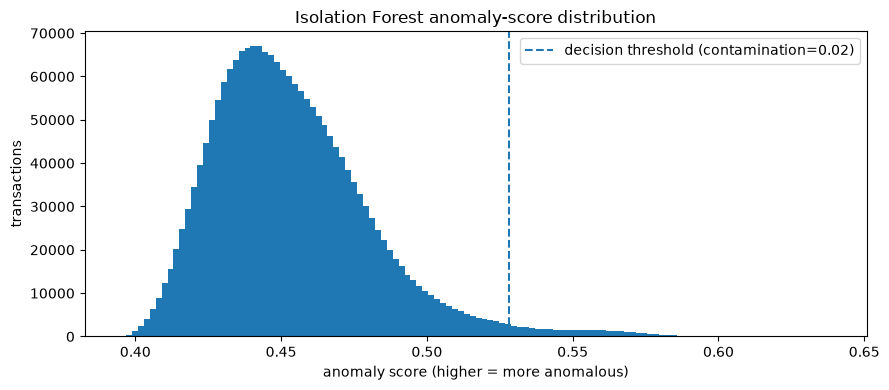


[CHECKPOINT] Top 20 most anomalous transactions (human sanity-check):


,txn_id,account_id,amount_npr,txn_type,channel,auth_method,hour_of_day,is_international,is_night,account_txn_count,amount_zscore_vs_account,anomaly_score
1811824,TXN-20260531-C1D511A0,ACC-4187908,3989589.87,SWIFT_OUTWARD,WEB,OTP_EMAIL,22,True,True,40,6.166,0.639
1910442,TXN-20250520-CE36AAF8,ACC-4771454,3327515.43,SWIFT_OUTWARD,WEB,OTP_EMAIL,22,True,True,30,2.235,0.636
1549200,TXN-20251222-D6B8D569,ACC-9158996,4425952.73,SWIFT_OUTWARD,WEB,OTP_SMS,2,True,True,49,2.937,0.634
219088,TXN-20250601-F9FC11DF,ACC-8141864,4802362.31,SWIFT_OUTWARD,WEB,OTP_EMAIL,20,True,False,49,6.857,0.634
1714424,TXN-20250420-0206732F,ACC-9975319,3495300.19,SWIFT_OUTWARD,MOBILE_APP,MPIN,0,True,True,42,2.380,0.632
1037880,TXN-20251123-7068C1DF,ACC-4321436,3233020.68,SWIFT_OUTWARD,WEB,BIOMETRIC,4,True,True,38,3.901,0.631
1531964,TXN-20260405-0B56E573,ACC-9800899,3172599.24,SWIFT_OUTWARD,WEB,CARD_PIN,1,True,True,38,2.233,0.631
1440537,TXN-20250315-C433A6A1,ACC-6754960,4876195.38,SWIFT_OUTWARD,WEB,CARD_PIN,13,True,False,59,5.000,0.629
1545065,TXN-20251102-B7AFA09B,ACC-8758155,4151428.21,SWIFT_OUTWARD,MOBILE_APP,OTP_EMAIL,23,True,True,61,3.542,0.629
574499,TXN-20251014-ACC0A501,ACC-2235644,2800726.68,SWIFT_OUTWARD,MOBILE_APP,BIOMETRIC,5,True,True,27,2.718,0.628


In [7]:
df["anomaly_score"] = -iso.score_samples(X_scaled)          # higher = more anomalous
df["is_anomaly"]    = iso.predict(X_scaled) == -1           # top ~2% under the assumed contamination

print(f"[CHECKPOINT] Scored {len(df):,} rows | flagged {df['is_anomaly'].sum():,} "
      f"({df['is_anomaly'].mean():.2%}) | score range [{df['anomaly_score'].min():.4f}, {df['anomaly_score'].max():.4f}]")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df["anomaly_score"], bins=120)
ax.axvline(df.loc[df["is_anomaly"], "anomaly_score"].min(), linestyle="--",
           label="decision threshold (contamination=0.02)")
ax.set_xlabel("anomaly score (higher = more anomalous)")
ax.set_ylabel("transactions")
ax.set_title("Isolation Forest anomaly-score distribution")
ax.legend()
plt.tight_layout()
plt.show()

TOP_N = 20
inspect_cols = ["txn_id", "account_id", "amount_npr", "txn_type", "channel",
                "auth_method", "hour_of_day", "is_international", "is_night",
                "account_txn_count", "amount_zscore_vs_account", "anomaly_score"]
top = df.nlargest(TOP_N, "anomaly_score")[inspect_cols]
print(f"\n[CHECKPOINT] Top {TOP_N} most anomalous transactions (human sanity-check):")
display(top.round(3))


## Optional — external check, **not used in training**

Joins `fraud_labels_train.csv` *after the fact* purely to see whether high anomaly
scores correlate with known fraud. PR-AUC here is a **diagnostic only** — the model
never saw these labels, and this cell can be skipped entirely.


In [8]:
# EXTERNAL CHECK, NOT USED IN TRAINING — diagnostic only.
if os.path.exists(LABELS_PATH):
    from sklearn.metrics import average_precision_score

    labels = pd.read_csv(LABELS_PATH)
    label_col = [c for c in labels.columns if c != "txn_id"][0]
    merged = df[["txn_id", "anomaly_score"]].merge(labels[["txn_id", label_col]], on="txn_id", how="inner")

    base_rate = merged[label_col].mean()
    pr_auc = average_precision_score(merged[label_col], merged["anomaly_score"])
    print(f"[DIAGNOSTIC] joined {len(merged):,} labeled rows | fraud base rate {base_rate:.4%}")
    print(f"[DIAGNOSTIC] PR-AUC of anomaly_score vs labels: {pr_auc:.4f} "
          f"(vs {base_rate:.4f} for a random ranker)")
    print("Reminder: unsupervised model — this measures correlation with known fraud, not model 'accuracy'.")
else:
    print("fraud_labels_train.csv not found — skipping external diagnostic (that's fine).")


[DIAGNOSTIC] joined 400,000 labeled rows | fraud base rate 1.8345%
[DIAGNOSTIC] PR-AUC of anomaly_score vs labels: 0.0200 (vs 0.0183 for a random ranker)
Reminder: unsupervised model — this measures correlation with known fraud, not model 'accuracy'.


## Step 7 — Save model, scaler, feature list, scored data (+ read-back verification)

Drive writes have truncated before, so every artifact is read back and its row/feature
count re-verified before we call this done.


In [9]:
MODEL_PATH   = os.path.join(MODEL_DIR, "isolation_forest_transactions_raw.joblib")
SCALER_PATH  = os.path.join(MODEL_DIR, "isolation_forest_scaler.joblib")
FEATURES_PATH = os.path.join(MODEL_DIR, "isolation_forest_feature_list.json")
SCORED_PATH  = os.path.join(PROCESSED_DIR, "transactions_scored_isoforest.csv")

joblib.dump(iso, MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

# Exact column order matters at inference: the forest was fit on this order.
with open(FEATURES_PATH, "w") as f:
    json.dump({
        "feature_columns": FEATURE_COLS,          # exact order for inference
        "scaled_columns": CONTINUOUS_COLS,        # columns the StandardScaler applies to
        "contamination_assumed": 0.02,
        "n_estimators": 200,
        "random_state": RANDOM_STATE,
        "trained_rows": int(len(df)),
    }, f, indent=2)

# Compact scored output (keys + score) — full 2M-row feature matrix stays local.
scored = df[["txn_id", "account_id", "timestamp", "amount_npr", "anomaly_score", "is_anomaly"]]
scored.to_csv(SCORED_PATH, index=False)

# --- read-back verification (Drive has truncated writes before) ---
iso_back    = joblib.load(MODEL_PATH)
scaler_back = joblib.load(SCALER_PATH)
feats_back  = json.load(open(FEATURES_PATH))
scored_back = pd.read_csv(SCORED_PATH, usecols=["txn_id"])

assert iso_back.n_features_in_ == len(FEATURE_COLS), "model read-back: feature count mismatch"
assert scaler_back.n_features_in_ == len(CONTINUOUS_COLS), "scaler read-back: feature count mismatch"
assert feats_back["feature_columns"] == FEATURE_COLS, "feature_list.json read-back mismatch"
assert len(scored_back) == len(df), f"scored CSV truncated: {len(scored_back):,} != {len(df):,}"

print("[CHECKPOINT] All artifacts saved and verified by read-back:")
print("  model   :", MODEL_PATH, f"({iso_back.n_features_in_} features)")
print("  scaler  :", SCALER_PATH, f"({scaler_back.n_features_in_} continuous features)")
print("  features:", FEATURES_PATH, f"({len(feats_back['feature_columns'])} columns)")
print("  scored  :", SCORED_PATH, f"({len(scored_back):,} rows)")
print("\nDONE — pipeline complete.")


[CHECKPOINT] All artifacts saved and verified by read-back:
  model   : C:\Developer\Agentic-Fraud-Detection-System-\backend\models\isolation_forest_transactions_raw.joblib (50 features)
  scaler  : C:\Developer\Agentic-Fraud-Detection-System-\backend\models\isolation_forest_scaler.joblib (8 continuous features)
  features: C:\Developer\Agentic-Fraud-Detection-System-\backend\models\isolation_forest_feature_list.json (50 columns)
  scored  : C:\Developer\Agentic-Fraud-Detection-System-\backend\datasets_processed\transactions_scored_isoforest.csv (1,999,998 rows)

DONE — pipeline complete.
